# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [17]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [22]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek

import matplotlib.pyplot as plt
import scipy.stats as stats

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))
    # Histogram
    plt.subplot(1,3,1)
    plt.hist(df_california[kolom], bins=30)
    plt.title(f'Histogram {kolom}')

    # Q-Q Plot
    plt.subplot(1,3,2)
    stats.probplot(df_california[kolom], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot {kolom}')

    # Boxplot
    plt.subplot(1,3,3)
    plt.boxplot(df_california[kolom], vert=False)
    plt.title(f'Boxplot {kolom}')

    plt.show()

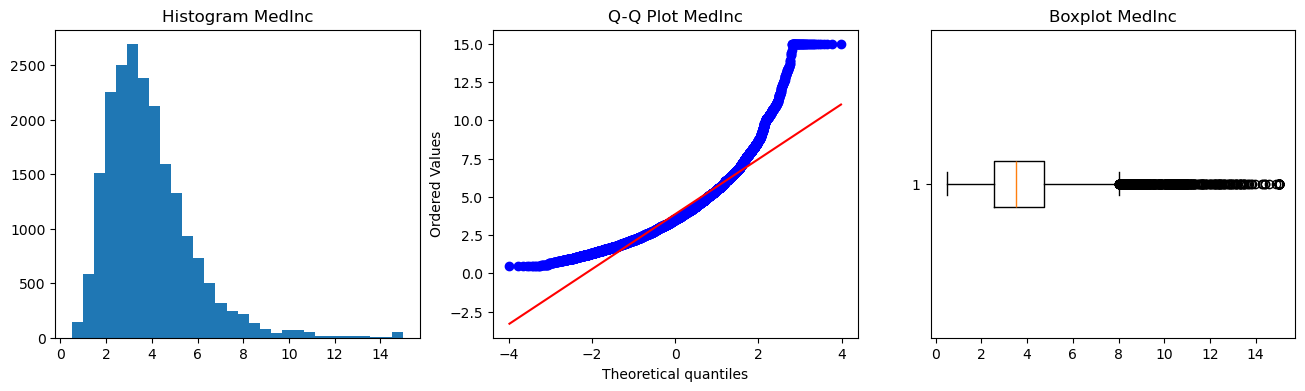

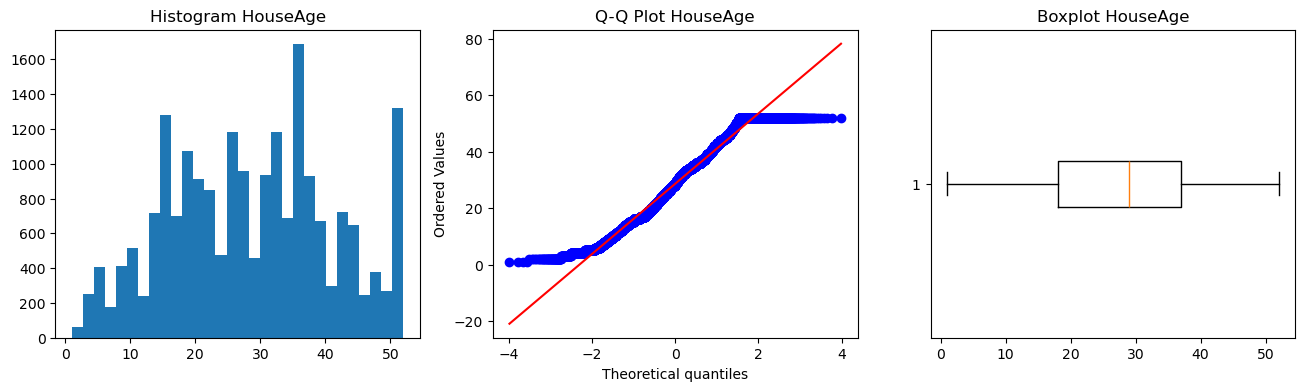

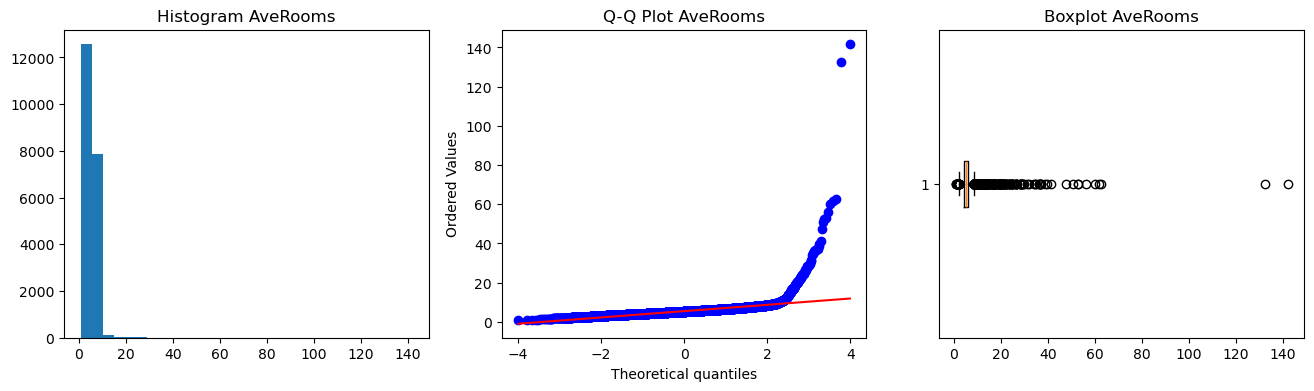

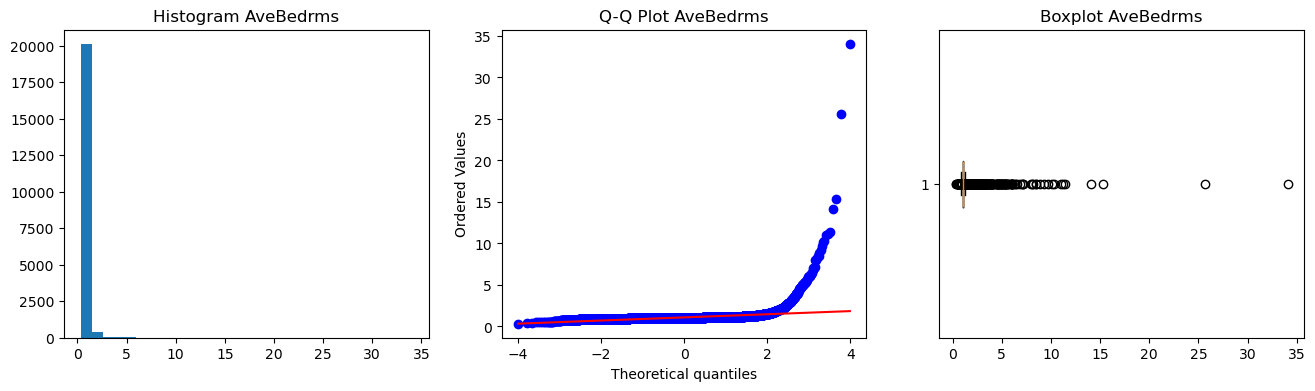

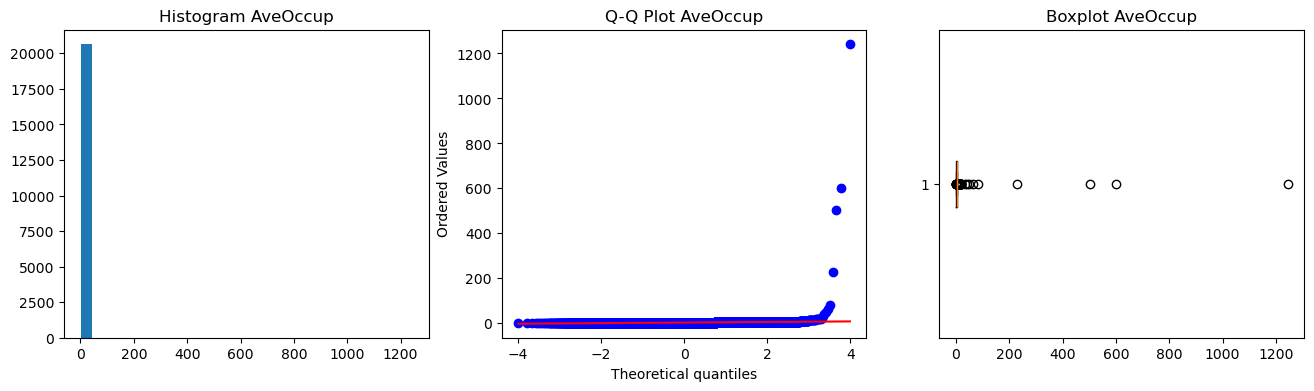

In [27]:
for kolom in kolom_kolom :

    check_plot(train_clfr, kolom_kolom)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [18]:
def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [19]:
HouseAge_upper_limit, HouseAge_lower_limit = find_outlier_boundary(train_clfr, 'HouseAge')

HouseAge_upper_limit, HouseAge_lower_limit

(np.float64(65.5), np.float64(-10.5))

In [20]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
import numpy as np

train_clfr['HouseAge'] = np.where(
    train_clfr['HouseAge'] > HouseAge_upper_limit,
    HouseAge_upper_limit,
    np.where(
        train_clfr['HouseAge'] < HouseAge_lower_limit,
        HouseAge_lower_limit,
        train_clfr['HouseAge']
    )
)

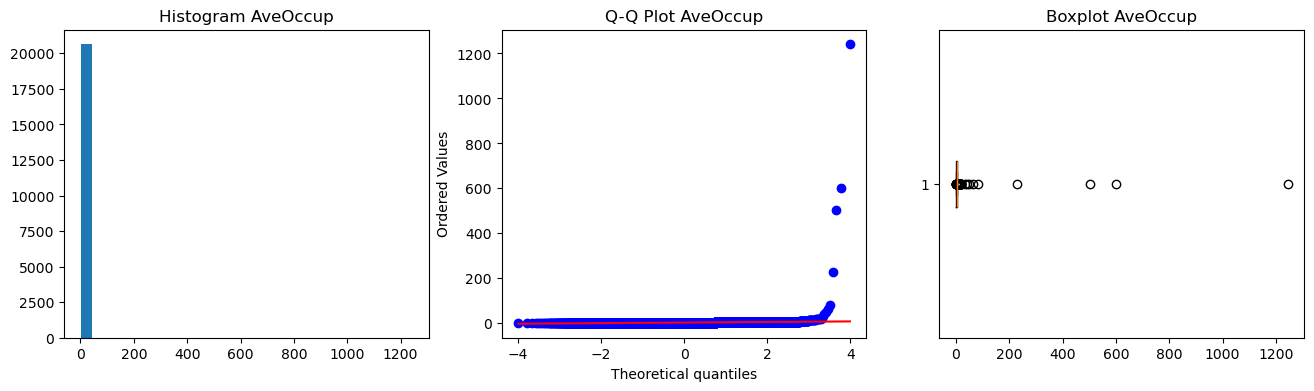

In [28]:
# Melakukan loop untuk mengecek distribusi tiap kolom
check_plot(train_clfr, 'HouseAge')

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [7]:
df_company = pd.read_csv('company.csv')

In [8]:
from feature_engine.outliers import ArbitraryOutlierCapper

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [13]:
df_company.head()


,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [14]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [15]:
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print()

============= Revenue =================


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============= Size =================


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============= Rating =================


Rating
 3.5    58
-1.0    50
 3.3    41
 4.0    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.4    31
 3.6    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 4.3    14
 2.9    14
 3.1    12
 4.6    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.3     1
 2.4     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============= Headquarters =================


Headquarters
New York, NY         33
San Francisco, CA    31
-1                   31
Chicago, IL          23
Boston, MA           19
                     ..
Oakville, Canada      1
San Bruno, CA         1
West Chester, PA      1
Utica, MI             1
Fort Lee, NJ          1
Name: count, Length: 229, dtype: int64

In [17]:
df_company = df_company.drop(columns=['Headquarters'])
df_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Revenue  672 non-null    object 
 1   Size     672 non-null    object 
 2   Rating   672 non-null    float64
dtypes: float64(1), object(2)
memory usage: 15.9+ KB


In [10]:
#Tulis jawaban missing value handling kolom Headquarters disini
100 * len(df_company[df_company['Headquarters']==-1]) / len(df_company) #untuk menghitung persentase data dengan nilai Rating = -1 dalam dataset

0.0

In [23]:
100 * len(df_company[df_company['Size'].isin(['-1','Headquarters'])]) / len(df_company) #Menghitung persentase data yang kolom Size-nya bernilai '-1' atau 'Unknown'

4.017857142857143

In [25]:
100 * len(df_company[df_company['Revenue'].isin(['-1','Headquarters / Non-Applicable'])]) / len(df_company)

4.017857142857143

In [36]:
df_company = df_company.drop(columns=['Headquarters'])
df_company.info()

KeyError: "['Headquarters'] not found in axis"

In [31]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size = 0.2, random_state=42)

In [34]:
# cek missing
train_company['Headquarters'].isnull().sum()

# ambil modus
mode_headquarters = train_company['Headquarters'].mode()[0]

# imputasi
train_company['Headquarters'].fillna(mode_headquarters, inplace=True)

KeyError: 'Headquarters'

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [ ]:
df_churn = pd.read_csv('Telco-Customer-Churn.csv')

In [ ]:
#Splitting terlebih dahulu


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [ ]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder


## Selesai :)